# Lab type: review
# Course: ML203 — Unsupervised Learning & Clustering
# Lesson: Choosing k
# Task: Evaluate the k-selection methods below. Answer the judgment questions in the comment cells.


In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


## Step 1: Generate Data


In [2]:
np.random.seed(42)

# Create clusters with varying sizes
cluster_1 = np.random.normal([2, 2], 0.8, (80, 2))
cluster_2 = np.random.normal([8, 8], 0.8, (60, 2))
cluster_3 = np.random.normal([2, 8], 0.8, (40, 2))

X = np.vstack([cluster_1, cluster_2, cluster_3])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Data shape: {X_scaled.shape}")


Data shape: (180, 2)


## Step 2: Review Elbow Method


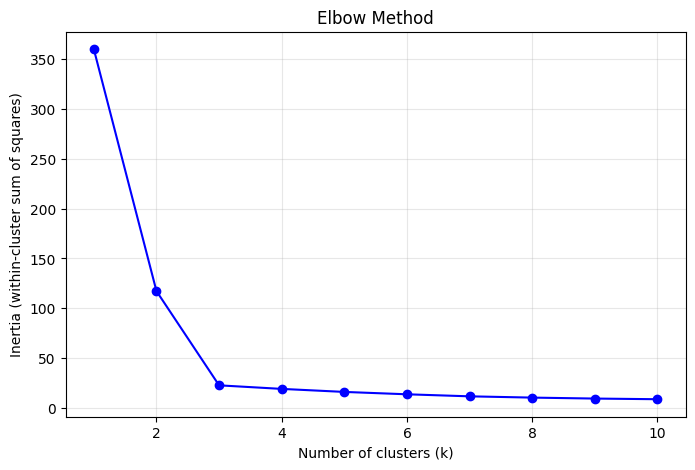

In [3]:
# Review this code — does it correctly identify the elbow?
inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow Method')
plt.grid(True, alpha=0.3)
plt.show()


**Question:** Looking at the elbow plot, where is the elbow? How confident are you in this choice? What would you do if the plot didn't have a clear elbow (as is often the case with real data)?


## Step 3: Review Silhouette Score


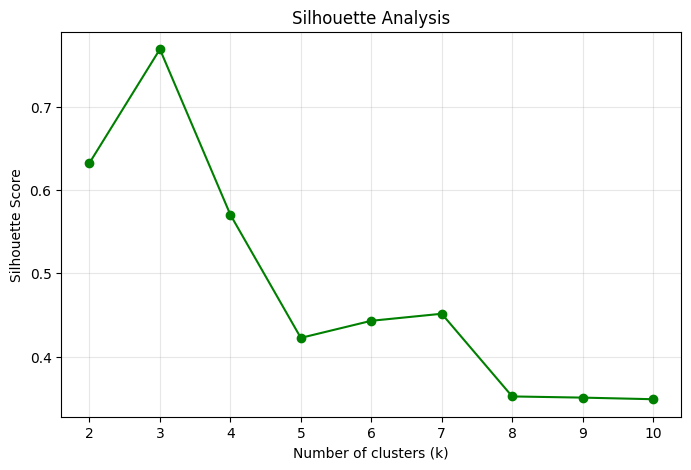

Best k by silhouette score: 3


In [5]:
# Review this code — does it rank k correctly?
silhouette_scores = []

# k_range is defined in the previous cell, but for clarity and isolated execution,
# let's redefine it to ensure it starts from 2 for silhouette score calculation.
k_range_silhouette = range(2, 11)

for k in k_range_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil_score)

plt.figure(figsize=(8, 5))
plt.plot(k_range_silhouette, silhouette_scores, 'go-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.grid(True, alpha=0.3)
plt.show()

best_k_silhouette = k_range_silhouette[np.argmax(silhouette_scores)]
print(f"Best k by silhouette score: {best_k_silhouette}")

**Question:** The silhouette score suggests one value of k. How does this compare to the elbow method's suggestion? When would you trust silhouette score over the elbow method, or vice versa?


## Step 4: Review Domain Knowledge Integration


In [6]:
# Review this code — is it reasonable?
# Suppose your business says: "We want to segment customers into 4 groups for marketing."
# The metrics suggest k=3, but the stakeholder insists on k=4.

k_business = 4
kmeans_business = KMeans(n_clusters=k_business, random_state=42, n_init=10)
labels_business = kmeans_business.fit_predict(X_scaled)

sil_score_k4 = silhouette_score(X_scaled, labels_business)
print(f"Silhouette score for k={k_business}: {sil_score_k4:.3f}")
print(f"Compare to best silhouette (k={best_k_silhouette}): {silhouette_scores[best_k_silhouette-1]:.3f}")


Silhouette score for k=4: 0.570
Compare to best silhouette (k=3): 0.570


**Question:** If metrics recommend k=3 but your stakeholder wants k=4, how would you decide? What information would you present to justify your recommendation?


## Summary

Choosing k is not automatic. You need multiple sources of evidence:
- **Elbow method:** Look for a kink in the inertia curve (often ambiguous)
- **Silhouette score:** Higher is better; shows cluster cohesion and separation
- **Domain knowledge:** What k makes sense for your use case?

Combine all three. If they disagree, investigate why before deciding.

**Next lesson:** DBSCAN — a different approach that doesn't require you to specify k upfront.
